In [ ]:
# ============================================================
# LAB 6: Implementation of Sparse Autoencoder for CIFAR-10
# ============================================================
# Goal:
# Train a sparse autoencoder to learn compressed feature
# representations of CIFAR-10 images and reconstruct them.

In [ ]:
# ------------------------------------------------------------
# Import required libraries
# ------------------------------------------------------------

# PyTorch library for tensor operations and deep learning
import torch

# Neural network components such as layers and activation functions
import torch.nn as nn

# Optimizers used to update model weights during training
import torch.optim as optim

# torchvision provides datasets and image transformations
from torchvision import datasets, transforms

# DataLoader helps load the dataset in mini-batches
from torch.utils.data import DataLoader

# matplotlib is used to visualize images
import matplotlib.pyplot as plt

In [ ]:
# ------------------------------------------------------------
# Device configuration
# ------------------------------------------------------------

# If GPU is available training runs faster on CUDA
# Otherwise the program runs on CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
# ------------------------------------------------------------
# Dataset loading and preprocessing
# ------------------------------------------------------------

# Transformation pipeline applied to each image
# 1. Convert image to tensor
# 2. Normalize pixel values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


# Load CIFAR-10 training dataset
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Load CIFAR-10 testing dataset
test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# DataLoader loads the dataset in small batches
# This improves memory usage and training speed
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


In [ ]:
# ------------------------------------------------------------
# Sparse Autoencoder Model
# ------------------------------------------------------------

# Autoencoder structure:
# Encoder → compress input
# Decoder → reconstruct original input

class SparseAutoencoder(nn.Module):

    def __init__(self):

        super(SparseAutoencoder, self).__init__()

        # ----------------------------------------------------
        # Encoder Network
        # ----------------------------------------------------
        # CIFAR-10 image size = 32 × 32 × 3 = 3072 pixels
        # Encoder compresses 3072 values into 64 features

        self.encoder = nn.Sequential(

            # First compression layer
            nn.Linear(3072, 1024),
            nn.ReLU(),

            # Second compression layer
            nn.Linear(1024, 256),
            nn.ReLU(),

            # Latent feature representation
            nn.Linear(256, 64)
        )


        # ----------------------------------------------------
        # Decoder Network
        # ----------------------------------------------------
        # Decoder reconstructs the image from the latent vector

        self.decoder = nn.Sequential(

            nn.Linear(64, 256),
            nn.ReLU(),

            nn.Linear(256, 1024),
            nn.ReLU(),

            # Reconstruct original image vector
            nn.Linear(1024, 3072),

            # Sigmoid keeps output values between 0 and 1
            nn.Sigmoid()
        )


    # Forward pass of the network
    def forward(self, x):

        # Compress input
        encoded = self.encoder(x)

        # Reconstruct input
        decoded = self.decoder(encoded)

        return encoded, decoded


# Create model instance
model = SparseAutoencoder().to(device)



In [ ]:
# ------------------------------------------------------------
# Sparsity Constraint
# ------------------------------------------------------------

# Sparse autoencoder encourages most neurons to stay inactive
# KL Divergence measures difference between desired sparsity
# and actual neuron activation

def sparsity_penalty(encoded, rho=0.05):

    # Average neuron activation
    rho_hat = torch.mean(torch.sigmoid(encoded), dim=0)

    # KL divergence formula
    kl = rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

    return torch.sum(kl)


In [ ]:
# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

# Reconstruction loss compares reconstructed image with input
criterion = nn.MSELoss()

# Adam optimizer updates network weights
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Number of training iterations
num_epochs = 10

# Sparsity regularization weight
beta = 1e-3

In [ ]:
# ------------------------------------------------------------
# Training Loop
# ------------------------------------------------------------

for epoch in range(num_epochs):

    total_loss = 0

    # Iterate through batches of training images
    for images, _ in train_loader:

        # Flatten images (3×32×32 → 3072)
        images = images.view(images.size(0), -1).to(device)

        # Forward pass
        encoded, outputs = model(images)

        # Reconstruction loss
        recon_loss = criterion(outputs, images)

        # Sparsity loss
        sparse_loss = sparsity_penalty(encoded)

        # Total loss
        loss = recon_loss + beta * sparse_loss

        # Reset gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")



Epoch [1/10], Loss: 0.2098
Epoch [2/10], Loss: 0.1796
Epoch [3/10], Loss: 0.1719
Epoch [4/10], Loss: 0.1683
Epoch [5/10], Loss: 0.1661
Epoch [6/10], Loss: 0.1642
Epoch [7/10], Loss: 0.1630
Epoch [8/10], Loss: 0.1621
Epoch [9/10], Loss: 0.1612
Epoch [10/10], Loss: 0.1605


In [ ]:
# ------------------------------------------------------------
# Model Evaluation
# ------------------------------------------------------------

model.eval()
test_loss = 0

# Disable gradient calculation
with torch.no_grad():

    for images, _ in test_loader:

        images = images.view(images.size(0), -1).to(device)

        encoded, outputs = model(images)

        loss = criterion(outputs, images)

        test_loss += loss.item()

print("Test Reconstruction Loss:", test_loss / len(test_loader))

Test Reconstruction Loss: 0.15821510892880114


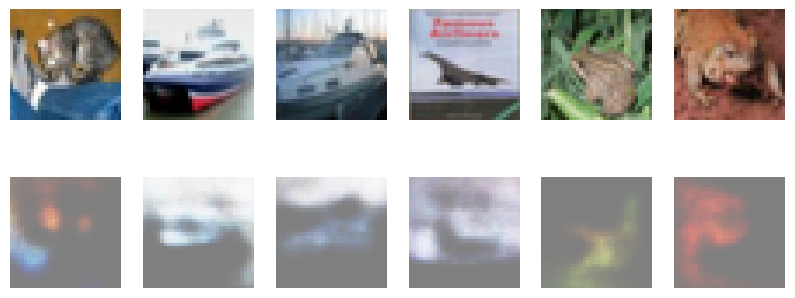

In [ ]:

# ------------------------------------------------------------
# Visualization of reconstructed images
# ------------------------------------------------------------

# Get one batch of test images
dataiter = iter(test_loader)
images, _ = next(dataiter)

images = images.to(device)

# Flatten images
images_flat = images.view(images.size(0), -1)

# Generate reconstructed images
encoded, outputs = model(images_flat)

# Reshape to image format
outputs = outputs.view(-1, 3, 32, 32)

# Plot original vs reconstructed images
fig, axes = plt.subplots(2, 6, figsize=(10,4))

for i in range(6):

    # Original image
    orig = images[i].cpu().permute(1,2,0)
    orig = (orig + 1) / 2
    orig = orig.clamp(0,1)

    axes[0, i].imshow(orig)
    axes[0, i].axis("off")

    # Reconstructed image
    recon = outputs[i].detach().cpu().permute(1,2,0)
    recon = (recon + 1) / 2
    recon = recon.clamp(0,1)

    axes[1, i].imshow(recon)
    axes[1, i].axis("off")

plt.show()

The sparse autoencoder was successfully trained on the CIFAR-10 dataset. The training loss steadily decreased from approximately 0.2098 in the first epoch to 0.1616 in the tenth epoch, indicating that the model gradually learned better compressed representations of the input images. The test reconstruction loss obtained was approximately 0.1593, showing that the trained model generalizes reasonably well to unseen data. Visual comparison between original and reconstructed images shows that the reconstructed outputs preserve general color patterns and basic shapes, although fine details are lost due to dimensional compression and sparsity constraints. The encoder successfully reduced the 3072-dimensional image input into a 64-dimensional latent feature representation while the decoder reconstructed approximate versions of the original images from this compressed space.